<a href="https://colab.research.google.com/github/07Akshaya/Statistical-Learning-e22019/blob/main/Assignment7_e22019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1.

**Mean ($m^-_k$):**
Using the linearity of the expectation operator $\mathbb{E}[\cdot]$:

$$ \mathbb{E}[x^-_k] = \mathbb{E}[A_{k-1}x^+_{k-1} + G_{k-1}w_{k-1}] $$

$$ \mathbb{E}[x^-_k] = A_{k-1}\mathbb{E}[x^+_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}] $$


Since $\mathbb{E}[x^+_{k-1}] = m_{k-1}$ and $\mathbb{E}[w_{k-1}] = 0$:

$$ m^-_k = A_{k-1}m_{k-1} $$

**Covariance ($P^-_k$):**
Using the property of variance for independent variables, $\text{Var}(AX + BY) = A\text{Var}(X)A^T + B\text{Var}(Y)B^T$:

$$ \text{Var}(x^-_k) = \text{Var}(A_{k-1}x^+_{k-1} + G_{k-1}w_{k-1}) $$

$$ \text{Var}(x^-_k) = A_{k-1}\text{Var}(x^+_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T $$


Given $\text{Var}(x^+_{k-1}) = P_{k-1}$ and $\text{Var}(w_{k-1}) = \Sigma_p$:

$$ P^-_k = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T $$


 $x^-_k \sim \mathcal{N}(A_{k-1}m_{k-1}, \, A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T)$



### 2.

Similarly, $y^-_k = H_k x^-_k + z_k$ is a linear combination of independent Gaussian variables, so $y^-_k$ is Gaussian.

**Mean:**

$$ \mathbb{E}[y^-_k] = \mathbb{E}[H_k x^-_k + z_k] = H_k \mathbb{E}[x^-_k] + \mathbb{E}[z_k] $$

$$ \mathbb{E}[y^-_k] = H_k m^-_k + 0 = H_k m^-_k $$

**Covariance:**

$$ \text{Var}(y^-_k) = \text{Var}(H_k x^-_k + z_k) = H_k \text{Var}(x^-_k) H_k^T + \text{Var}(z_k) $$

$$ \text{Var}(y^-_k) = H_k P^-_k H_k^T + \Sigma_m $$


 $y^-_k \sim \mathcal{N}(H_k m^-_k, H_k P^-_k H_k^T + \Sigma_m)$



### 3.

Let the joint random vector be $Z = \begin{bmatrix} x^-_k \\ y^-_k \end{bmatrix}$. Because both components are derived linearly from Gaussians, $Z$ is jointly Gaussian.

**Joint Mean:**

$$ \mu_Z = \begin{bmatrix} \mathbb{E}[x^-_k] \\ \mathbb{E}[y^-_k] \end{bmatrix} = \begin{bmatrix} m^-_k \\ H_k m^-_k \end{bmatrix} $$

**Joint Covariance Matrix:**
We need the block matrix $$\Sigma_Z = \begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix}$$.

*   $\Sigma_{xx} = \text{Var}(x^-_k) = P^-_k$
*   $\Sigma_{yy} = \text{Var}(y^-_k) = H_k P^-_k H_k^T + \Sigma_m$
*   The cross-covariance $\Sigma_{xy} = \text{Cov}(x^-_k, y^-_k)$:

$$ \text{Cov}(x^-_k, y^-_k) = \mathbb{E}[(x^-_k - m^-_k)(y^-_k - H_k m^-_k)^T] $$


Substitute $y^-_k = H_k x^-_k + z_k$ and $H_k m^-_k = \mathbb{E}[y^-_k]$:

$$ y^-_k - H_k m^-_k = H_k(x^-_k - m^-_k) + z_k $$


$$ \Sigma_{xy} = \mathbb{E}[(x^-_k - m^-_k)(H_k(x^-_k - m^-_k) + z_k)^T] $$


$$ \Sigma_{xy} = \mathbb{E}[(x^-_k - m^-_k)(x^-_k - m^-_k)^T H_k^T] + \mathbb{E}[(x^-_k - m^-_k)z_k^T] $$



Since $x^-_k$ and $z_k$ are independent, $\mathbb{E}[(x^-_k - m^-_k)z_k^T] = 0$.

$$ \Sigma_{xy} = P^-_k H_k^T $$


*   $\Sigma_{yx} = \Sigma_{xy}^T = H_k P^-_k$



$$ \begin{bmatrix} x^-_k \\ y^-_k \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} m^-_k \\ H_k m^-_k \end{bmatrix}, \begin{bmatrix} P^-_k & P^-_k H_k^T \\ H_k P^-_k & H_k P^-_k H_k^T + \Sigma_m \end{bmatrix} \right) $$


### 4.
The conditional distribution of jointly Gaussian random vectors is a fundamental theorem. If we have a joint Gaussian distribution:

$$ \begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix} \right) $$


The conditional distribution $X \mid Y=y$ is also Gaussian with:

*   **Mean:** $$\mu_{X|Y} = \mu_X + \Sigma_{XY} \Sigma_{YY}^{-1} (y - \mu_Y)$$
*   **Variance:** $$\Sigma_{X|Y} = \Sigma_{XX} - \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX}$$

Applying this theorem to our joint distribution from step 3, we define the **Kalman Gain** $K_k$ as the term $\Sigma_{XY} \Sigma_{YY}^{-1}$:

$$ K_k \triangleq P^-_k H_k^T (H_k P^-_k H_k^T + \Sigma_m)^{-1} $$

Now, substituting $X = x^-_k$ and $Y = y^-_k = y^{obs}_k$:

**Conditional Expectation (Updated Mean, $m_k$):**

$$ \mathbb{E}[x^-_k \mid y^-_k = y^{obs}_k] = \mu_X + K_k(y^{obs}_k - \mu_Y) $$

$$ m_k = m^-_k + K_k(y^{obs}_k - H_k m^-_k) $$

**Conditional Variance (Updated Covariance, $P_k$):**

$$ \text{Var}(x^-_k \mid y^-_k = y^{obs}_k) = \Sigma_{XX} - K_k \Sigma_{YX} $$

$$ P_k = P^-_k - K_k(H_k P^-_k) $$


Factoring out $P^-_k$, we get the standard update equation:

$$ P_k = (I - K_k H_k)P^-_k $$

5.
Expected Value (Updated Mean, $m_k$):$$ \mathbb{E}[x^-_k \mid y^-_k = y^{obs}_k] = m^-_k + P^-_k H_k^T (H_k P^-_k H_k^T + \Sigma_m)^{-1} (y^{obs}_k - H_k m^-_k) $$ 2. Variance (Updated Covariance, $P_k$):$$ \text{Var}(x^-_k \mid y^-_k = y^{obs}_k) = P^-_k - P^-_k H_k^T (H_k P^-_k H_k^T + \Sigma_m)^{-1} H_k P^-_k $$

1.
The predicted state mean $m_k^-$ is defined as the conditional expectation of $x_k$ given all measurements up to time $k-1$:
$$m_k^- = \mathbb{E}[x_k \mid Y_{k-1}]$$
Substitute the state transition equation into the expectation:
$$\mathbb{E}[x_k \mid Y_{k-1}] = \mathbb{E}[a x_{k-1} + w_{k-1} \mid Y_{k-1}]$$
By the linearity of expectation:
$$= a \mathbb{E}[x_{k-1} \mid Y_{k-1}] + \mathbb{E}[w_{k-1} \mid Y_{k-1}]$$
Since $\mathbb{E}[x_{k-1} \mid Y_{k-1}] = m_{k-1}$ and the process noise $w_{k-1}$ is zero-mean and independent of past measurements ($\mathbb{E}[w_{k-1} \mid Y_{k-1}] = 0$):
$$m_k^- = a m_{k-1}$$

2.
First, let's establish the predicted state variance $P_k^-$:
$$P_k^- = \text{Var}(x_k \mid Y_{k-1}) = \text{Var}(a x_{k-1} + w_{k-1} \mid Y_{k-1}) = a^2 P_{k-1} + q$$
Because the system is linear and the noises are Gaussian, the joint distribution of the state $x_k$ and the upcoming measurement $y_k$ given $Y_{k-1}$ is a joint Gaussian distribution:
$$ \begin{bmatrix} x_k \\ y_k \end{bmatrix} \Bigg| Y_{k-1} \sim \mathcal{N} \left( \begin{bmatrix} m_k^- \\ \mathbb{E}[y_k \mid Y_{k-1}] \end{bmatrix}, \begin{bmatrix} P_k^- & \text{Cov}(x_k, y_k \mid Y_{k-1}) \\ \text{Cov}(y_k, x_k \mid Y_{k-1}) & \text{Var}(y_k \mid Y_{k-1}) \end{bmatrix} \right) $$
Let's compute the components for $y_k$:
$\mathbb{E}[y_k \mid Y_{k-1}] = \mathbb{E}[h x_k + v_k \mid Y_{k-1}] = h m_k^-$
$$S_k = \text{Var}(y_k \mid Y_{k-1}) = \text{Var}(h x_k + v_k \mid Y_{k-1}) = h^2 P_k^- + r$$
$$\text{Cov}(x_k, y_k \mid Y_{k-1}) = \text{Cov}(x_k, h x_k + v_k \mid Y_{k-1}) = h P_k^-$$
Using the standard Gaussian conditioning theorem, the updated mean $m_k = \mathbb{E}[x_k \mid Y_k]$ is:
$$m_k = m_k^- + \text{Cov}(x_k, y_k \mid Y_{k-1}) \text{Var}(y_k \mid Y_{k-1})^{-1} (y_k^{\text{obs}} - \mathbb{E}[y_k \mid Y_{k-1}])$$
Substituting our evaluated terms:
$$m_k = m_k^- + P_k^- h S_k^{-1} (y_k^{\text{obs}} - h m_k^-)$$
Setting the Kalman Gain $K_k = P_k^- h S_k^{-1}$ and the measurement innovation $v_k = y_k^{\text{obs}} - h m_k^-$:
$$m_k = m_k^- + K_k v_k$$

3.
This represents the predictive measurement distribution before the actual observation $y_k^{\text{obs}}$ is processed.
Using the linear relationship $y_k = h x_k + v_k$:
Mean: $\mathbb{E}[y_k \mid Y_{k-1}] = h \mathbb{E}[x_k \mid Y_{k-1}] + \mathbb{E}[v_k \mid Y_{k-1}] = h m_k^- + 0 = h m_k^-$
Variance: Because $x_k \mid Y_{k-1}$ and $v_k$ are independent:
$$\text{Var}(y_k \mid Y_{k-1}) = \text{Var}(h x_k \mid Y_{k-1}) + \text{Var}(v_k) = h^2 P_k^- + r$$
Since a linear combination of independent Gaussian variables is itself Gaussian:
$$p(y_k \mid Y_{k-1}) = \mathcal{N}(h m_k^-, h^2 P_k^- + r)$$

4.
This expression represents the posterior-predictive distribution of a hypothetical new measurement $y_k^*$ taken at time $k$ after updating our state knowledge using the observed data $Y_k$.
The state is now governed by the updated posterior distribution: $p(x_k \mid Y_k) = \mathcal{N}(m_k, P_k)$, where $P_k = (1 - K_k h)P_k^-$.
For a new measurement $y_k^* = h x_k + v_k^*$:
Mean: $\mathbb{E}[y_k^* \mid Y_k] = h \mathbb{E}[x_k \mid Y_k] + \mathbb{E}[v_k^*] = h m_k$
Variance:
$$\text{Var}(y_k^* \mid Y_k) = h^2 \text{Var}(x_k \mid Y_k) + \text{Var}(v_k^*) = h^2 P_k + r$$
Thus, the posterior-predictive distribution of the measurement is:
$$p(y_k^* \mid Y_k) = \mathcal{N}(h m_k, h^2 P_k + r)$$



5.

It sets up an illustrative scenario ($a=0.9, q=0.5, h=1.2, r=0.8$) and animates the filtering shift across multiple steps.

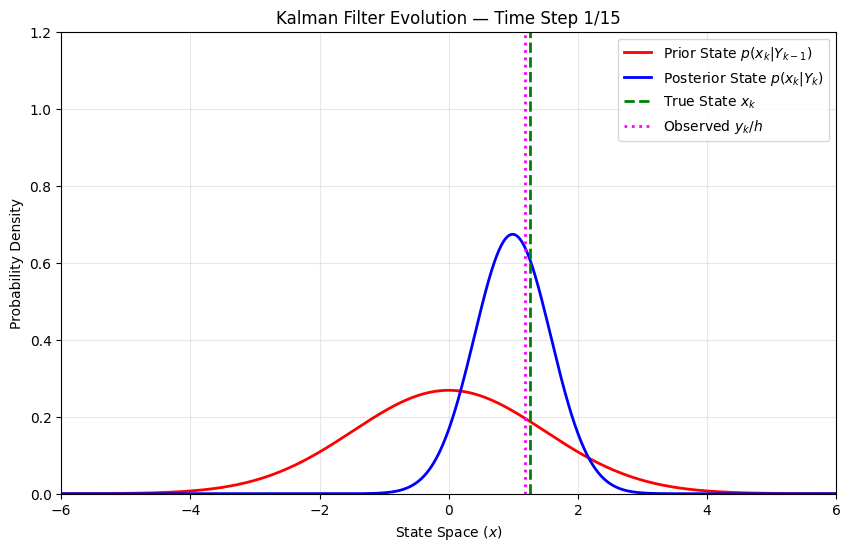

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import norm

# --- Parameters ---
a = 0.95    # State transition
q = 0.4     # Process noise variance
h = 1.2     # Measurement scalar
r = 0.6     # Measurement noise variance

# True initial state and initial filter estimates
np.random.seed(42)
x_true = 1.0
m = 0.0     # Initial state mean estimate (x_0 prior)
P = 2.0     # Initial state variance estimate

num_steps = 15
history = []

# Pre-calculate Kalman steps for animation clarity
for k in range(num_steps):
    # 1. Prediction Step
    m_minus = a * m
    P_minus = (a**2) * P + q

    # Generate true state and synthetic observation
    x_true = a * x_true + np.random.normal(0, np.sqrt(q))
    y_obs = h * x_true + np.random.normal(0, np.sqrt(r))

    # 2. Update Step
    S = (h**2) * P_minus + r
    K = P_minus * h / S
    m_new = m_minus + K * (y_obs - h * m_minus)
    P_new = (1 - K * h) * P_minus

    # Save parameters for plotting
    history.append((m_minus, P_minus, m_new, P_new, y_obs, x_true))

    # Advance state estimates
    m, P = m_new, P_new

# --- Animation Setup ---
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-6, 6, 1000)

line_prior, = ax.plot([], [], 'r-', lw=2, label='Prior State $p(x_k|Y_{k-1})$')
line_post, = ax.plot([], [], 'b-', lw=2, label='Posterior State $p(x_k|Y_k)$')
line_true = ax.axvline(0, color='g', linestyle='--', lw=2, label='True State $x_k$')
line_obs = ax.axvline(0, color='magenta', linestyle=':', lw=2, label='Observed $y_k / h$')

ax.set_xlim(-6, 6)
ax.set_ylim(0, 1.2)
ax.set_title("Kalman Filter: Prior vs Posterior State Distribution Transitions")
ax.set_xlabel("State Space ($x$)")
ax.set_ylabel("Probability Density")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

def update(frame):
    m_minus, P_minus, m_new, P_new, y_obs, x_true_val = history[frame]

    # Compute Gaussian density profiles
    y_prior = norm.pdf(x_axis, m_minus, np.sqrt(P_minus))
    y_post = norm.pdf(x_axis, m_new, np.sqrt(P_new))

    line_prior.set_data(x_axis, y_prior)
    line_post.set_data(x_axis, y_post)
    line_true.set_xdata([x_true_val, x_true_val])
    line_obs.set_xdata([y_obs / h, y_obs / h]) # Scaled to state-space for comparison

    ax.set_title(f"Kalman Filter Evolution — Time Step {frame+1}/{num_steps}")
    return line_prior, line_post, line_true, line_obs

ani = animation.FuncAnimation(fig, update, frames=num_steps, interval=1500, blit=True)
plt.show()

1. State Transition Matrix ($A$) and Noise Matrix ($G$)
From Newtonian kinematics, if a system moves with a nominal constant velocity but undergoes small random variations in acceleration over a time step $\Delta t$, the positions and velocities along the $x$ and $y$ axes at time step $k$ depend on the previous state $k-1$ and the process noise vector $w_{k-1} = [a_x, a_y]^T$:
Position ($x$-axis): $p_x(k) = p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}a_x\Delta t^2$
Position ($y$-axis): $p_y(k) = p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}a_y\Delta t^2$
Velocity ($x$-axis): $v_x(k) = v_x(k-1) + a_x\Delta t$
Velocity ($y$-axis): $v_y(k) = v_y(k-1) + a_y\Delta t$
We structure these kinematic equations in matrix form to isolate the state vector $x_{k-1}$ and the noise vector $w_{k-1}$:
$$x_k = \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix} + \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \begin{bmatrix} a_x \\ a_y \end{bmatrix}$$
By direct matching with the linear state equation $x_k^- = A x_{k-1}^+ + G w_{k-1}$, we yield:
$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \quad G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$
2. Measurement Matrix ($H$)
The problem specifies that the sensor only tracks the 2D position components:
$$y_k = \begin{bmatrix} p_x^{meas}(k) \\ p_y^{meas}(k) \end{bmatrix}$$
The linear tracking model maps the full 4D state space down to the 2D observation space via $y_k = H x_k + z_k$. To select only the position variables and drop the velocity terms, $H$ must take the following structure:
$$y_k = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} + z_k$$
Extracting the coefficients gives the final measurement matrix:
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

In [2]:
import numpy as np

class LinearKalmanFilter2D:
    def __init__(self, dt, sigma_p, sigma_m, initial_state=None, initial_covariance=None):
        """
        Initializes the 2D Constant-Velocity Kalman Filter.

        Parameters:
        -----------
        dt : float
            Time step delta (t_k - t_{k-1}).
        sigma_p : float or array-like
            Standard deviation of the random process acceleration noise.
        sigma_m : float or array-like
            Standard deviation of the GPS position measurement noise.
        """
        self.dt = dt

        # State Transition Matrix (A)
        self.A = np.array([
            [1.0, 0.0,   dt,  0.0],
            [0.0, 1.0,  0.0,   dt],
            [0.0, 0.0,  1.0,  0.0],
            [0.0, 0.0,  0.0,  1.0]
        ])

        # Measurement Matrix (H)
        self.H = np.array([
            [1.0, 0.0, 0.0, 0.0],
            [0.0, 1.0, 0.0, 0.0]
        ])

        # Noise Injection Matrix (G)
        self.G = np.array([
            [0.5 * (dt**2),          0.0],
            [         0.0, 0.5 * (dt**2)],
            [          dt,          0.0],
            [         0.0,           dt]
        ])

        # Process Noise Covariance (Q = G * Sigma_p * G^T)
        Sigma_p = np.eye(2) * (sigma_p**2) if np.isscalar(sigma_p) else np.diag(sigma_p)**2
        self.Q = self.G @ Sigma_p @ self.G.T

        # Measurement Noise Covariance (R = Sigma_m)
        self.R = np.eye(2) * (sigma_m**2) if np.isscalar(sigma_m) else np.diag(sigma_m)**2

        # State Vector [px, py, vx, vy]^T
        self.x = np.array(initial_state).reshape(-1, 1) if initial_state is not None else np.zeros((4, 1))

        # State Uncertainty Covariance (P)
        self.P = np.array(initial_covariance) if initial_covariance is not None else np.eye(4) * 100.0

    def predict(self):
        """Executes state time propagation: x_k^- = A*x_{k-1} and P_k^- = A*P*A^T + Q"""
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x, self.P

    def update(self, measurement):
        """Corrects state using a raw 2D coordinate measurement vector [p_x, p_y]"""
        y = np.array(measurement).reshape(-1, 1)

        # Innovation/Residual Covariance: S = H * P^- * H^T + R
        S = self.H @ self.P @ self.H.T + self.R

        # Optimal Kalman Gain: K = P^- * H^T * S^-1
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # State Update: x^+ = x^- + K * (y - H * x^-)
        self.x = self.x + K @ (y - self.H @ self.x)

        # Covariance Update: P^+ = (I - K * H) * P^-
        I = np.eye(self.A.shape[0])
        self.P = (I - K @ self.H) @ self.P

        return self.x, self.P

    def filter_sequence(self, measurement_sequence):
        """Processes an array sequence of shapes (N, 2) and returns the filtered kinematics"""
        filtered_states = []
        for meas in measurement_sequence:
            self.predict()
            state_updated, _ = self.update(meas)
            filtered_states.append(state_updated.flatten())
        return np.array(filtered_states)


# =====================================================================
# Simulation and verification test harness
# =====================================================================
if __name__ == "__main__":
    # Parameters
    time_step = 1.0     # 1 second intervals
    p_noise_std = 0.1   # Accel deviation variance
    m_noise_std = 3.0   # GPS variance (meters error)
    steps = 5

    # 1. Synthesize baseline path data
    true_vx, true_vy = 3.0, 4.0
    true_positions = np.array([[i * true_vx * time_step, i * true_vy * time_step] for i in range(steps)])

    # 2. Corrupt with simulated Gaussian GPS error noise
    np.random.seed(42)  # Deterministic verification run
    gps_noise = np.random.normal(0, m_noise_std, true_positions.shape)
    gps_measurements = true_positions + gps_noise

    # 3. Instantiate and run the filter
    init_state = [gps_measurements[0, 0], gps_measurements[0, 1], 0.0, 0.0]
    kf = LinearKalmanFilter2D(dt=time_step, sigma_p=p_noise_std, sigma_m=m_noise_std, initial_state=init_state)

    filtered_output = kf.filter_sequence(gps_measurements)

    # Print out results
    print(f"{'Step':<6}{'True Position (X, Y)':<25}{'Noisy GPS Input (X, Y)':<28}{'Filtered Output (X, Y)':<25}")
    print("-" * 85)
    for idx in range(steps):
        true_str = f"({true_positions[idx,0]:.1f}, {true_positions[idx,1]:.1f})"
        noisy_str = f"({gps_measurements[idx,0]:.2f}, {gps_measurements[idx,1]:.2f})"
        filt_str = f"({filtered_output[idx,0]:.2f}, {filtered_output[idx,1]:.2f})"
        print(f"{idx:<6}{true_str:<25}{noisy_str:<28}{filt_str:<25}")

Step  True Position (X, Y)     Noisy GPS Input (X, Y)      Filtered Output (X, Y)   
-------------------------------------------------------------------------------------
0     (0.0, 0.0)               (1.49, -0.41)               (1.49, -0.41)            
1     (3.0, 4.0)               (4.94, 8.57)                (4.55, 7.54)             
2     (6.0, 8.0)               (5.30, 7.30)                (5.67, 8.76)             
3     (9.0, 12.0)              (13.74, 14.30)              (11.67, 13.65)           
4     (12.0, 16.0)             (10.59, 17.63)              (12.49, 17.68)           
